[![Text: CC BY-SA 4.0](https://img.shields.io/badge/text-CC%20BY--SA%204.0-lightgrey.svg)](https://creativecommons.org/licenses/by-sa/4.0/)
[![Code: MIT](https://img.shields.io/badge/code-MIT-yellow.svg)](https://opensource.org/license/mit)

This notebook is part of course materials for CS 545: Machine Learning at
Colorado State University. These notebooks are based on the PyTorch version of
[Dive into Deep Learning](https://d2l.ai) by Aston Zhang, Zachary C. Lipton,
Mu Li and Alexander J. Smola, used under
[CC BY-SA 4.0](https://creativecommons.org/licenses/by-sa/4.0/) and heavily
modified by [Asa Ben-Hur](https://www.cs.colostate.edu/~asa/) with
[Claude](https://claude.com) AI. The text is released under
[CC BY-SA 4.0](https://creativecommons.org/licenses/by-sa/4.0/); the code is
released under the [MIT license](https://opensource.org/license/mit).

# Minibatches and Momentum

The last notebook left two problems.

**One example per step wastes the hardware.**  SGD's step is $n$ times cheaper
than gradient descent's in *arithmetic*, but arithmetic is not what modern
processors are short of.  Minibatching recovers the difference.

**One learning rate cannot serve directions of different curvature.**  We saw
this in miniature on $f = x_1^2 + 2x_2^2$, where the curvature ratio was only
two.  This notebook builds a problem where the ratio is ten thousand — which is
the realistic case — and shows that momentum handles it and plain SGD does not.

Along the way, a warning about benchmarks.  It is easy to construct an
optimization demonstration on which every method looks identical — easy enough
that it is often done by accident.  We will build a problem where the
differences are real, and then show exactly which property of the data makes
them appear and disappear.

In [1]:
# render figures as crisp vector graphics (SVG) in the notebook
try:
    from matplotlib_inline.backend_inline import set_matplotlib_formats
    set_matplotlib_formats('svg')
except ImportError:
    pass

import matplotlib
matplotlib.rcParams['svg.fonttype'] = 'none'   # keep text as text in the SVG

import math
import time

import numpy as np
import torch
from torch import nn
from matplotlib import pyplot as plt

torch.manual_seed(0)

## Why minibatches

The last notebook ended on one example per step: the cheapest step available
and, as the noise floor showed, a poor one.  The full batch is the most accurate
step and, at $n$ gradient evaluations, an unaffordable one.  Batch size is the
dial between the two, and two independent things set it — how much accuracy an
extra example actually buys, which we measure a couple of cells below, and what
the hardware can do in a single call, which is this section.

Processing one example at a time means a sequence of matrix-vector products.
Processing $B$ at a time means one matrix-matrix product.  These have the same
number of multiply-accumulates, and wildly different running times, because a
matrix-vector product reads each weight from memory and uses it once, while a
matrix-matrix product reads it once and uses it $B$ times.  The limiting
resource is memory bandwidth, not arithmetic.

Exercise 1 asks you to measure this; how large the gap turns out to be depends
on the machine, on the linear algebra library and on the size of the matrices,
so it is worth measuring on the hardware you actually use.  On a GPU it is
largest of all — a modern accelerator has enough arithmetic units to do
thousands of multiply-accumulates per cycle and cannot come close to keeping
them fed one column at a time.

So the practical algorithm is neither of the two extremes.  **Minibatch
stochastic gradient descent** draws a batch $\mathcal{B}_t$ of $B$ examples and
uses

$$\mathbf{x} \leftarrow \mathbf{x} -
  \frac{\eta}{|\mathcal{B}_t|} \sum_{i \in \mathcal{B}_t} \nabla f_i(\mathbf{x}).$$

Two things improve at once.  The step is computed at close to peak throughput,
and the variance of the gradient estimate falls by a factor of $B$ — so its
standard deviation, which is what sets the noise floor, falls by $\sqrt{B}$.

That $\sqrt{B}$ is why batch size has diminishing returns.  Going from 1 to 100
cuts the gradient noise tenfold; going from 100 to 10,000 cuts it tenfold
again, at a hundred times the cost per step.  In practice the batch is chosen
as the largest that keeps the hardware busy without wasting memory —
commonly 32 to 512 — and not by an argument about noise at all.

Note also that batches are formed by shuffling and then partitioning, not by
sampling with replacement.  Each example is then seen exactly once per epoch,
which is the definition of an epoch we have been using all along.

## A problem to experiment on

The questions in this section — how big should a batch be, and what does batch
size buy — do not depend much on the problem, so almost any least-squares fit
will do.  We generate one rather than downloading one, for two reasons: it can
be resized at will, and generating it means we know the parameter vector
$\mathbf{w}^*$ that produced the data, which is worth having later.

In [2]:
def make_regression(n=2000, d=20, cond=1e2, noise=0.1, rotate=True, seed=0):
    """Least squares data: y = X w* + noise.

    The singular values of X are spaced geometrically over [1, sqrt(cond)];
    `cond` is left at its default until the momentum section, which is where
    it starts to matter.  With rotate=True the stretched directions are not the
    coordinate axes, which matters at the very end."""
    g = torch.Generator().manual_seed(seed)
    scale = torch.logspace(0, 0.5 * math.log10(cond), d)
    Z = torch.randn(n, d, generator=g) * scale
    if rotate:
        Q, _ = torch.linalg.qr(torch.randn(d, d, generator=g))
        X = Z @ Q.T
    else:
        X = Z
    X = X / X.std()                                    # fix the overall scale
    w_true = torch.randn(d, 1, generator=g)
    y = X @ w_true + noise * torch.randn(n, 1, generator=g)
    return X, y, w_true


X, y, w_true = make_regression()
floor = float(((X @ w_true - y) ** 2).mean() / 2)
print(f'X: {tuple(X.shape)},  ||w*|| = {float(w_true.norm()):.3f}')
print(f'the label noise puts a floor of {floor:.4f} under the training loss')

X: (2000, 20),  ||w*|| = 5.497
the label noise puts a floor of 0.0048 under the training loss


### How many examples does a step need?

Every gradient here is an average over the examples in the batch.  Take the
average over $m$ of them and ask how nearly it points the same way as the
average over all 2,000.

In [3]:
w0 = torch.zeros(X.shape[1], 1)               # the point every run starts from
per_example = X * (X @ w0 - y)                # one gradient per example
exact = per_example.mean(0)

generator = torch.Generator().manual_seed(0)
print('examples averaged   cosine with the exact gradient')
for m in [1, 2, 8, 32, 128, 512, len(X)]:
    cosines = []
    for _ in range(200):                      # 200 random subsets of size m
        subset = torch.randperm(len(X), generator=generator)[:m]
        sample = per_example[subset].mean(0)
        cosines.append(float(torch.dot(sample, exact)
                             / (sample.norm() * exact.norm())))
    print(f'{m:17d}   {np.mean(cosines):.3f}')

examples averaged   cosine with the exact gradient
                1   0.324
                2   0.464
                8   0.761
               32   0.928
              128   0.983
              512   0.997
             2000   1.000


One example points about $70^\circ$ away from the exact gradient: downhill, and
not much more.  Eight get to $0.76$, thirty-two to $0.93$ — and the remaining
1,968 examples buy the last $7\%$.  That is the redundancy of the previous
notebook in one column, and it is the statistical case for a batch of a few
dozen: enough examples to have a usable direction, few enough that we are not
paying for a direction we already have.

How many it takes depends on the problem — on how noisy the individual
gradients are and on how many parameters there are, which is why deep networks
use batches of hundreds rather than tens.  What it does not depend on is $n$:
the accuracy of an average is set by how many examples are in it, not by how
many are left out.  A full-batch step's cost grows with the training set and
the quality of its direction does not.

The training loop is deliberately plain — parameters, a data loader, and
whichever `torch.optim` optimizer we hand it — so that the only things varying
between the experiments below are the batch size and the optimizer.

In [4]:
def train(X, y, make_optimizer, epochs=30, batch_size=32, seed=1):
    """Fit a linear model; return the final weights and the per-epoch loss."""
    torch.manual_seed(seed)
    w = torch.zeros(X.shape[1], 1, requires_grad=True)
    b = torch.zeros(1, requires_grad=True)
    optimizer = make_optimizer([w, b])
    loader = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(X, y), batch_size=batch_size, shuffle=True)

    losses = []
    for _ in range(epochs):
        batch_losses = []
        for X_batch, y_batch in loader:
            loss = ((X_batch @ w + b - y_batch) ** 2).mean() / 2
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            batch_losses.append(loss.item())
        losses.append(float(np.mean(batch_losses)))
        if not math.isfinite(losses[-1]) or losses[-1] > 1e12:
            break                                       # diverged
    return w.detach(), losses

### Batch size, in epochs and in updates

Two axes worth keeping apart.  An **epoch** is one pass over the training set:
it costs the same arithmetic whatever the batch size, but it contains $n/B$
updates, so a large batch spends the pass on very few steps.  An **update** is
one optimizer step, and costs $B$ examples' worth of gradient.

The two panels below ask different questions.  On the left, each batch size
runs for 30 epochs at its own best learning rate — the same amount of data
each, and the question is how much progress the data bought.  On the right, all
three run for the same number of *updates* at the same learning rate, which
asks what changes about a step when it averages over more examples.

full batch (2000)  lr 0.3    loss after 30 epochs 0.1033
one example        lr 0.003  loss after 30 epochs 0.0048
minibatch (32)     lr 0.1    loss after 30 epochs 0.0049

batch 1    lr 0.01   loss after 6,000 updates 0.0054, wobble 0.068
batch 8    lr 0.01   loss after 6,000 updates 0.0052, wobble 0.012
batch 32   lr 0.01   loss after 6,000 updates 0.0052, wobble 0.010


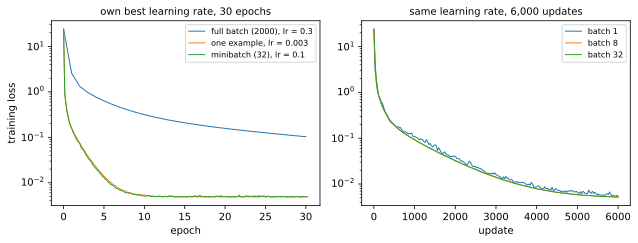

In [5]:
def loss_curve(batch_size, lr, updates, seed=1, points=200):
    """Train with plain SGD for a fixed number of updates, recording the loss
    on the whole training set as it goes."""
    torch.manual_seed(seed)
    w = torch.zeros(X.shape[1], 1, requires_grad=True)
    b = torch.zeros(1, requires_grad=True)
    optimizer = torch.optim.SGD([w, b], lr=lr)
    loader = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(X, y), batch_size=batch_size, shuffle=True)

    def full_loss():
        with torch.no_grad():
            return float(((X @ w + b - y) ** 2).mean() / 2)

    every = max(1, updates // points)
    steps, losses = [0], [full_loss()]
    step = 0
    while step < updates:
        for X_batch, y_batch in loader:
            loss = ((X_batch @ w + b - y_batch) ** 2).mean() / 2
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            step += 1
            if step % every == 0:
                steps.append(step)
                losses.append(full_loss())
            if step >= updates:
                break
    steps = np.array(steps)
    return steps, steps * batch_size / len(X), np.array(losses)


fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))

for label, batch_size, lr in [('full batch (2000)', 2000, 0.3),
                              ('one example', 1, 0.003),
                              ('minibatch (32)', 32, 0.1)]:
    _, epochs, losses = loss_curve(batch_size, lr,
                                   30 * math.ceil(len(X) / batch_size))
    axes[0].plot(epochs, losses, lw=1, label=f'{label}, lr = {lr:g}')
    print(f'{label:18s} lr {lr:<6g} loss after 30 epochs {losses[-1]:.4f}')

print()
for batch_size in [1, 8, 32]:
    steps, _, losses = loss_curve(batch_size, 0.01, 6000)
    axes[1].plot(steps, losses, lw=1, label=f'batch {batch_size}')
    settled = np.log(losses[steps > 1000])
    print(f'batch {batch_size:<4d} lr 0.01   loss after 6,000 updates '
          f'{losses[-1]:.4f}, wobble {np.diff(settled).std():.3f}')

for ax, xlabel in zip(axes, ['epoch', 'update']):
    ax.set_yscale('log'); ax.set_xlabel(xlabel); ax.legend(fontsize=8)
axes[0].set_ylabel('training loss')
axes[0].set_title('own best learning rate, 30 epochs', fontsize=10)
axes[1].set_title('same learning rate, 6,000 updates', fontsize=10)
plt.tight_layout()

**Per epoch, the full batch is the one that loses.**  Thirty epochs buys it
thirty steps, and it ends at a loss of $0.10$ — twenty times worse than the
other two, on identical data.  One example per step and a batch of 32 both
reach $0.005$, which is the floor set by the label noise: there is nothing left
in the data for them to fit.  This is the sense in which stochastic methods
converge faster — not per step, but per pass over the data, because a pass
contains so many more steps.

**Per update, a larger batch buys smoothness rather than progress.**  The three
curves in the right panel lie almost on top of one another and end within $4\%$
of each other: at a fixed learning rate a step is a step, whatever it averages
over.  This is the cosine table above showing up as a training
curve — averaging 32 examples instead of 1 bought a better-aimed step, not a
longer one, so the progress per step is unchanged.  What differs is the noise around that path.  Batch 1 is visibly ragged,
batch 8 nearly clean, and the measured wobble falls from $0.068$ to $0.010$.
The gradient noise itself falls only as $\sqrt{B}$, but the loss depends on the
*square* of how far that noise has displaced the parameters, so the wobble in
the curve falls faster — until it disappears under the shape of the curve
itself, which is why batch 32 looks little different from batch 8.

That smoothing is the reason minibatch curves are the ones you are used to
looking at.  It is also the reason to distrust them slightly: a smooth training
curve says the *estimate* of the loss is stable, which is not the same as the
optimizer being finished.  The right panel is generous to the large batches in
another way too — it gives every run the same number of updates, so batch 32
consumed thirty-two times the data to draw its cleaner line.  Neither panel is
the axis you actually pay in.

### Batch size, in time

The axis you pay in is wall-clock time, and it is the one on which the three
differ most.  Same three runs, plotted against seconds.

full batch (2000)    30 epochs in  0.23 s, final loss 0.1073
one example           3 epochs in  0.52 s, final loss 0.0556
minibatch (32)       30 epochs in  0.28 s, final loss 0.0051


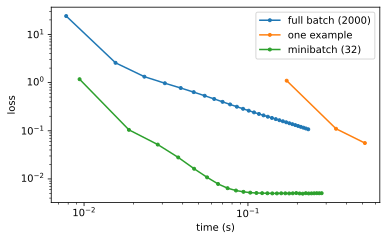

In [6]:
def timed(X, y, batch_size, lr, epochs):
    start = time.time()
    _, losses = train(X, y, lambda p: torch.optim.SGD(p, lr=lr),
                      epochs=epochs, batch_size=batch_size)
    per_epoch = (time.time() - start) / len(losses)
    return np.arange(1, len(losses) + 1) * per_epoch, losses

runs = {'full batch (2000)': timed(X, y, 2000, 0.3, 30),
        'one example':       timed(X, y, 1, 0.003, 3),
        'minibatch (32)':    timed(X, y, 32, 0.1, 30)}

plt.figure(figsize=(5.5, 3.5))
for label, (t, losses) in runs.items():
    plt.plot(t, losses, '-o', markersize=3, label=label)
    print(f'{label:20s} {len(losses):2d} epochs in {t[-1]:5.2f} s, '
          f'final loss {losses[-1]:.4f}')
plt.xscale('log'); plt.yscale('log')
plt.xlabel('time (s)'); plt.ylabel('loss'); plt.legend()
plt.tight_layout()

Full-batch gradient descent takes clean steps and very few of them.
One-example SGD makes far more progress per pass over the data but spends an
enormous amount of time doing it.  The minibatch run gets the good part of both
— which is why every training loop you have written in this course used one.

That settles the computational question.  The rest of the notebook is about the
quality of the step.

## One learning rate, two curvatures

Return to the two-dimensional picture, but with the curvatures now genuinely
mismatched: $f(\mathbf{x}) = 0.1x_1^2 + 2x_2^2$, whose second derivatives are
$0.2$ and $4$ — a ratio of 20.

after 20 steps, x1 = -0.94347, x2 = -0.00007


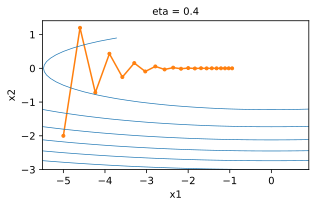

In [7]:
def show_trace_2d(f, trace, title=None, xlim=(-5.5, 1.0), ylim=(-3.0, 1.0)):
    plt.figure(figsize=(4.5, 3))
    plt.plot(*zip(*trace), '-o', color='#ff7f0e', markersize=3)
    g1, g2 = torch.meshgrid(torch.arange(*xlim, 0.1),
                            torch.arange(*ylim, 0.1), indexing='ij')
    plt.contour(g1, g2, f(g1, g2), colors='#1f77b4', linewidths=0.7)
    plt.xlabel('x1'); plt.ylabel('x2')
    if title:
        plt.title(title, fontsize=10)
    plt.tight_layout()


def train_2d(trainer, steps=20, init=(-5, -2)):
    x1, x2 = init
    s1 = s2 = 0
    trace = [(x1, x2)]
    for _ in range(steps):
        x1, x2, s1, s2 = trainer(x1, x2, s1, s2)
        trace.append((x1, x2))
    print(f'after {steps} steps, x1 = {x1:.5f}, x2 = {x2:.5f}')
    return trace


def f_valley(x1, x2):
    return 0.1 * x1 ** 2 + 2 * x2 ** 2

def gd_valley(x1, x2, s1, s2):
    return x1 - eta * 0.2 * x1, x2 - eta * 4 * x2, 0, 0

eta = 0.4
show_trace_2d(f_valley, train_2d(gd_valley), 'eta = 0.4')

The path zigzags across a narrow valley and creeps along it.  The steps in
$x_2$, the steep direction, are large enough to overshoot and come back; the
steps in $x_1$, the flat direction, are tiny.  After twenty steps $x_2$ is
essentially solved and $x_1$ has barely moved.

The natural response is to raise the learning rate to speed up $x_1$.

after 20 steps, x1 = -0.38781, x2 = -1673.36511


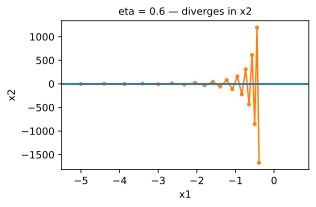

In [8]:
eta = 0.6
show_trace_2d(f_valley, train_2d(gd_valley), 'eta = 0.6 — diverges in x2')

And $x_2$ diverges.  This is the bind, and it has nothing to do with noise —
these gradients are exact.  **The learning rate is capped by the steepest
direction and the convergence rate is set by the flattest one.**  With a
condition number of 20 there is a workable compromise.  With $10^4$ there is
not.

## Momentum

Look again at the zigzag.  The $x_2$ component of the gradient alternates sign
from step to step, because we keep overshooting.  The $x_1$ component keeps the
same sign for the whole run, because we are steadily descending a long shallow
slope.  Consecutive gradients therefore carry a signal we are throwing away:
directions that *persist* are worth moving further in, and directions that
*reverse* are worth damping.

Averaging does both at once.  Keep a running average of past gradients,

$$\mathbf{v}_t = \beta \mathbf{v}_{t-1} + \mathbf{g}_t,
\qquad
\mathbf{x}_t = \mathbf{x}_{t-1} - \eta \mathbf{v}_t,$$

with $\beta \in [0, 1)$.  In the flat direction the aligned gradients
accumulate and $\mathbf{v}$ grows; in the steep direction the alternating signs
cancel and $\mathbf{v}$ stays small.  Expanding the recursion,

$$\mathbf{v}_t = \sum_{\tau=0}^{t-1} \beta^{\tau} \mathbf{g}_{t-\tau},$$

which is a weighted sum with geometrically decaying weights.  Since
$\sum_{\tau} \beta^\tau = \frac{1}{1-\beta}$, the update is effectively an
average over about $\frac{1}{1-\beta}$ past gradients, scaled up by that same
factor.  For $\beta = 0.9$ that is ten gradients; for $\beta = 0.99$, a hundred.
This is why increasing $\beta$ usually requires decreasing $\eta$: the two
multiply.

The name is apt.  $\mathbf{v}$ behaves like a velocity, the gradient like a
force, and $\beta$ like friction.  A ball rolling down the valley does not
zigzag.

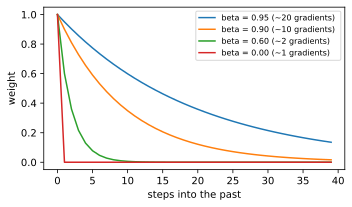

In [9]:
betas = [0.95, 0.9, 0.6, 0.0]
plt.figure(figsize=(5, 3))
for beta in betas:
    tau = np.arange(40)
    plt.plot(tau, beta ** tau, label=f'beta = {beta:.2f}  '
                                     f'(~{1 / (1 - beta):.0f} gradients)')
plt.xlabel('steps into the past'); plt.ylabel('weight')
plt.legend(fontsize=8); plt.tight_layout()

after 20 steps, x1 = 0.00719, x2 = 0.00255


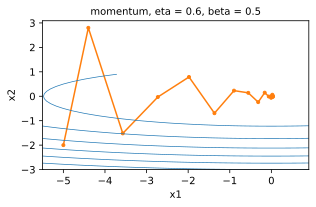

In [10]:
def momentum_2d(x1, x2, v1, v2):
    v1 = beta * v1 + 0.2 * x1
    v2 = beta * v2 + 4 * x2
    return x1 - eta * v1, x2 - eta * v2, v1, v2

eta, beta = 0.6, 0.5
show_trace_2d(f_valley, train_2d(momentum_2d), 'momentum, eta = 0.6, beta = 0.5')

At the learning rate that made plain gradient descent diverge, momentum
converges — and reaches $x_1$ far faster than the stable $\eta = 0.4$ run did.
Both effects come from the same averaging.

The parameter $\beta$ has an optimum, not a monotone effect.  Too small and
there is nothing to average; too large and the velocity carries so much history
that the optimizer overshoots on a scale of many steps.

In [11]:
for beta_value in [0.0, 0.25, 0.5, 0.9]:
    beta = beta_value
    print(f'beta = {beta:.2f}:', end=' ')
    train_2d(momentum_2d)

beta = 0.00: after 20 steps, x1 = -0.38781, x2 = -1673.36511
beta = 0.25: after 20 steps, x1 = -0.12634, x2 = -0.18663
beta = 0.50: after 20 steps, x1 = 0.00719, x2 = 0.00255
beta = 0.90: after 20 steps, x1 = -1.19164, x2 = -1.11846


## From the picture to a training run

Now the experiment the two-dimensional pictures were an argument for: twenty
parameters, minibatches, `torch.optim` — an ordinary training loop.  The data
is generated rather than collected, which is the price of being able to check
the answer against the $\mathbf{w}^*$ that produced it; the ill-conditioning it
has is the kind real data has, and the next-to-last section of this notebook
shows how to tell the two kinds apart.

Two things have to be set up first: a problem hard enough for the difference to
show, and a measurement that can see it.

### How hard is a problem?  The condition number

For a least-squares objective $f(\mathbf{w}) = \frac{1}{2n}\|X\mathbf{w} - y\|^2$
the Hessian is the constant matrix $H = \frac{1}{n} X^\top X$.  Its eigenvalues
are the curvatures along the principal directions of the problem.  The
**condition number** is the ratio

$$\kappa = \frac{\lambda_{\max}}{\lambda_{\min}}$$

between the largest and the smallest.  From the last notebook we know the
largest usable learning rate is set by $\lambda_{\max}$ — anything above
roughly $2/\lambda_{\max}$ diverges.  And the rate of progress along the
flattest direction is governed by $\eta \lambda_{\min}$.  Putting those
together: with the largest stable learning rate, the number of steps needed to
make progress along the flattest direction is proportional to $\kappa$.

A well-conditioned problem has $\kappa$ near 1 and every optimizer solves it.
A problem with $\kappa = 10^4$ needs ten thousand times as many steps in its
worst direction as in its best, and *that* is where the choice of method
starts to matter.  Deep networks are firmly in the second category.

That is what the `cond` argument of `make_regression` controls: it sets the
singular values of $X$ directly.  The problem everything above ran on has
$\kappa \approx 100$ — hard enough that the number of steps in a pass mattered,
as the batch-size experiments showed, and not hard enough for the choice of
*update rule* to matter at all, as we are about to see.

In [12]:
def condition_number(X):
    eigenvalues = torch.linalg.eigvalsh(X.T @ X / X.shape[0])
    return eigenvalues.min().item(), eigenvalues.max().item(), \
        (eigenvalues.max() / eigenvalues.min()).item()


for cond in [1e2, 1e4]:
    X_c, _, _ = make_regression(cond=cond)
    lo, hi, kappa = condition_number(X_c)
    print(f'cond = {cond:.0e}:  Hessian eigenvalues {lo:.2e} to {hi:.2e},  '
          f'condition number {kappa:,.0f}')

cond = 1e+02:  Hessian eigenvalues 4.37e-02 to 4.34e+00,  condition number 99
cond = 1e+04:  Hessian eigenvalues 7.80e-04 to 7.73e+00,  condition number 9,902


### What to measure

Because we generated the data ourselves we know the true $\mathbf{w}^*$, and
we will report two numbers for every run: the training loss, and the
**relative parameter error** $\|\mathbf{w} - \mathbf{w}^*\| / \|\mathbf{w}^*\|$.
Keep an eye on the fact that we can measure both.  It turns out to matter a
great deal which one you look at.

The comparison has to be made carefully.  Momentum changes the effective step
size, so running both methods at the *same* learning rate would mean comparing
a tuned method against an untuned one.  We instead give each method its own
sweep and report its best result — which is what a practitioner would do, and
the only comparison that says anything.

In [13]:
GRID = [1e-3, 3e-3, 1e-2, 3e-2, 1e-1, 3e-1]

def best_over_grid(X, y, w_true, make_optimizer, grid=GRID, **kwargs):
    """Train once per learning rate; keep the run with the lowest parameter error."""
    results = []
    for lr in grid:
        w, losses = train(X, y, lambda p, lr=lr: make_optimizer(p, lr), **kwargs)
        error = (float((w - w_true).norm() / w_true.norm())
                 if torch.isfinite(w).all() else float('inf'))
        results.append({'error': error, 'lr': lr, 'loss': losses[-1],
                        'curve': losses, 'w': w})
    return min(results, key=lambda r: r['error'])


METHODS = {
    'SGD':      lambda p, lr: torch.optim.SGD(p, lr=lr),
    'momentum': lambda p, lr: torch.optim.SGD(p, lr=lr, momentum=0.9),
}

def compare(X, y, w_true, label):
    kappa = condition_number(X)[2]
    print(f'{label}  (condition number {kappa:,.0f})')
    runs = {}
    for name, make in METHODS.items():
        runs[name] = best_over_grid(X, y, w_true, make)
        print(f'    {name:9s} best lr {runs[name]["lr"]:<6g} '
              f'training loss {runs[name]["loss"]:.4f}    '
              f'parameter error {runs[name]["error"]:.4f}')
    return runs

Sweep the condition number.  This takes a few seconds per row.

In [14]:
for cond in [1e2, 1e3, 1e4]:
    X_c, y_c, w_c = make_regression(cond=cond)
    compare(X_c, y_c, w_c, f'target condition number {cond:.0e}')
    print()

target condition number 1e+02  (condition number 99)
    SGD       best lr 0.1    training loss 0.0051    parameter error 0.0045
    momentum  best lr 0.01   training loss 0.0050    parameter error 0.0045

target condition number 1e+03  (condition number 992)
    SGD       best lr 0.3    training loss 0.0086    parameter error 0.0119
    momentum  best lr 0.03   training loss 0.0054    parameter error 0.0107

target condition number 1e+04  (condition number 9,902)
    SGD       best lr 0.1    training loss 0.0088    parameter error 0.4334
    momentum  best lr 0.1    training loss 0.0084    parameter error 0.0713



Two things are going on here, and the second is the more important.

**First, momentum wins, and only when the problem is hard.**  At $\kappa = 99$
the two methods are indistinguishable: both land at a parameter error of about
$0.0045$, which is the noise floor of the data, and there is nothing for
momentum to fix.  At $\kappa \approx 9{,}900$ plain SGD ends about $43\%$ away
from the true parameters while momentum is about $7\%$ away — roughly **six
times better**, each at its own best learning rate, with the same number of
gradient evaluations.

**Second — and look at this carefully — the training loss does not show it.**
At $\kappa \approx 9{,}900$ the two methods report losses of roughly $0.009$
and $0.008$.  By that measure they are equally converged, and by the parameter
error one of them is not converged at all.

This is not a quirk of the example; it follows from the geometry.  Writing the
error in the eigenbasis of the Hessian as $\mathbf{e} = \mathbf{w} - \mathbf{w}^*$,
the excess loss is

$$f(\mathbf{w}) - f(\mathbf{w}^*) = \tfrac{1}{2}\sum_i \lambda_i e_i^2 .$$

Each direction's contribution is weighted by its **curvature**.  The flat
directions — precisely the ones SGD cannot make progress in, because
$\eta\lambda_i$ is tiny — have $\lambda_i$ small, so leaving them completely
unsolved costs almost nothing in the loss.  With $\kappa = 10^4$, an error of
$1$ in the flattest direction shows up in the loss ten thousand times more
weakly than the same error in the steepest one.

It is easier to see than to say.  The set of parameter values whose loss is
within $\varepsilon$ of the best possible is an ellipse — the same ellipse the
contour plots have been drawing all along — with semi-axes
$\sqrt{2\varepsilon / \lambda_i}$.  Those axes are stretched by
$\sqrt{\kappa}$: ten to one at $\kappa = 100$, a hundred to one at
$\kappa = 10^4$.

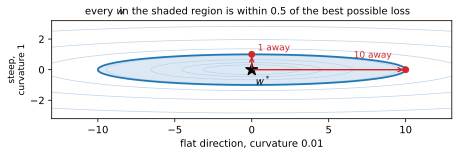

In [15]:
lam_flat, lam_steep = 0.01, 1.0        # two curvatures, a ratio of 100
epsilon = 0.5                          # a rise in loss too small to notice


def f_schematic(x1, x2):
    return 0.5 * (lam_flat * x1 ** 2 + lam_steep * x2 ** 2)


far = math.sqrt(2 * epsilon / lam_flat)         # how far epsilon reaches, flat
near = math.sqrt(2 * epsilon / lam_steep)       # and steep

g1, g2 = np.linspace(-13, 13, 600), np.linspace(-3.2, 3.2, 300)
G1, G2 = np.meshgrid(g1, g2, indexing='ij')
F = f_schematic(G1, G2)

plt.figure(figsize=(6.5, 2.6))
plt.contourf(G1, G2, F, levels=[0, epsilon], colors=['#dce9f5'])
plt.contour(G1, G2, F, levels=np.geomspace(0.05, 4, 7),
            colors='#bcd2e8', linewidths=0.7)
plt.contour(G1, G2, F, levels=[epsilon], colors='#1f77b4', linewidths=1.8)
plt.plot(0, 0, '*', color='black', markersize=13, zorder=3)
plt.annotate(r'$w^*$', (0, 0), textcoords='offset points', xytext=(4, -16))

for point, offset in [((far, 0), (-52, 12)), ((0, near), (6, 4))]:
    plt.annotate('', xy=point, xytext=(0, 0),
                 arrowprops=dict(arrowstyle='->', color='#d62728', lw=1.4))
    plt.plot(*point, 'o', color='#d62728', markersize=6, zorder=3)
    plt.annotate(f'{max(point):.0f} away', point, textcoords='offset points',
                 xytext=offset, color='#d62728', fontsize=9)

plt.gca().set_aspect('equal')
plt.xlabel('flat direction, curvature 0.01')
plt.ylabel('steep,\ncurvature 1', fontsize=9)
plt.title(f'every $w$ in the shaded region is within {epsilon} of the best '
          f'possible loss', fontsize=10)
plt.tight_layout()

Both marked points cost the same: each raises the loss by $\varepsilon$ above
its minimum.  One of them is ten times further from $\mathbf{w}^*$ than the
other.  At $\kappa = 10^4$ it would be a hundred times further — and on a real
network, with curvatures spanning far more than that, the shaded region is a
sliver in a space of millions of dimensions.

**A small loss gap therefore does not bound the distance to the solution.**  It
bounds it only in the steep directions, and those are exactly the ones every
optimizer solves first.  It is worth carrying that further than this notebook:
a flat training curve does not by itself mean an optimizer has finished, only
that it has finished in the directions the loss can see.  On a real network you
have no $\mathbf{w}^*$ to compare against, which is one of several reasons
validation metrics — not the training loss — are what you actually watch.

The two runs on the hard problem show it happening.  Alongside the loss curves,
the cell below reports the excess loss $\tfrac{1}{2}\sum_i \lambda_i e_i^2$ and
the single worst direction of each solution.

the hard problem  (condition number 9,902)
    SGD       best lr 0.1    training loss 0.0088    parameter error 0.4334
    momentum  best lr 0.1    training loss 0.0084    parameter error 0.0713
SGD       excess loss 0.00381   worst direction: off by 2.36 where the curvature is 1.2e-03
momentum  excess loss 0.00297   worst direction: off by 0.37 where the curvature is 1.2e-03


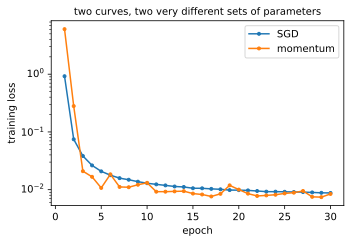

In [16]:
X_hard, y_hard, w_hard = make_regression(cond=1e4)
runs = compare(X_hard, y_hard, w_hard, 'the hard problem')

eigenvalues, eigenvectors = torch.linalg.eigh(X_hard.T @ X_hard / len(X_hard))

plt.figure(figsize=(5, 3.5))
for name, run in runs.items():
    plt.plot(np.arange(1, len(run['curve']) + 1), run['curve'],
             '-o', markersize=3, label=name)
    e = (eigenvectors.T @ (run['w'] - w_hard)).squeeze(1)    # error per direction
    worst = int(e.abs().argmax())
    print(f'{name:9s} excess loss {float((0.5 * eigenvalues * e ** 2).sum()):.5f}'
          f'   worst direction: off by {float(e[worst].abs()):.2f} '
          f'where the curvature is {float(eigenvalues[worst]):.1e}')
plt.yscale('log'); plt.xlabel('epoch'); plt.ylabel('training loss')
plt.title('two curves, two very different sets of parameters', fontsize=10)
plt.legend(); plt.tight_layout()

Two curves you would call converged, lying on top of each other from about
epoch 10 — and the parameters behind them are not remotely the same.  Almost
all of SGD's error sits in one direction, where it is off by $2.4$ against
momentum's $0.37$.  The curvature there is $\lambda_i \approx
1.25\times10^{-3}$, so that error contributes
$\tfrac{1}{2}\lambda_i e_i^2 \approx 0.0035$ to the loss: the excess loss of the
two solutions differs by a factor of $1.3$ while their distance from
$\mathbf{w}^*$ differs by a factor of $6$.  The weighting shrinks the visible
cost of the error by exactly the factor that made the direction hard to
optimize in the first place.

## Does standardizing the features fix this?

Standardizing each feature to zero mean and unit variance is a habit you have
been taught to practise, and it is fair to ask whether it makes any of this
unnecessary — whether the preprocessing has already dealt with the
ill-conditioning before an optimizer ever sees the problem.

Standardizing does change the condition number.  Whether it *fixes* it depends
entirely on where the ill-conditioning came from, and there are two sources.

**Axis-aligned**: the features are uncorrelated but measured on different
scales — one in metres, one in millimetres.  The Hessian is nearly diagonal
with very unequal entries.

**Rotated**: the features are correlated, so the stretched directions of the
Hessian are combinations of features rather than individual ones.

Build one of each with the same condition number and standardize both.

In [17]:
def standardize(X):
    return (X - X.mean(0)) / X.std(0)

for rotate, label in [(False, 'axis-aligned (uncorrelated, unequal scales)'),
                      (True,  'rotated (correlated features)')]:
    X_r, _, _ = make_regression(cond=1e4, rotate=rotate)
    print(f'{label}')
    print(f'    raw          condition number {condition_number(X_r)[2]:10,.0f}')
    print(f'    standardized condition number '
          f'{condition_number(standardize(X_r))[2]:10,.0f}')

axis-aligned (uncorrelated, unequal scales)
    raw          condition number      9,905
    standardized condition number          1
rotated (correlated features)
    raw          condition number      9,902
    standardized condition number      7,009


Standardizing takes the axis-aligned problem from about $10^4$ down to
essentially **1** — it solves it completely.  On the rotated problem it manages
a reduction of well under a factor of two, from about $9{,}900$ to about
$7{,}000$, leaving the difficulty entirely intact.  That is not surprising once
stated: dividing each feature by
its standard deviation rescales the *coordinate axes*, which is precisely a
diagonal correction, and a diagonal correction can only fix a diagonal problem.

This is also how an optimization benchmark comes to show nothing.  Give a
method a problem whose ill-conditioning is axis-aligned, standardize the
features as a matter of routine, and the problem arrives *solved* — every
method then converges at the same rate and the comparison says nothing about
the methods.  It is worth knowing which of the two kinds of ill-conditioning a
benchmark has before reading its result.

The lesson generalizes past this notebook.  Standardizing inputs is worth doing
and it is cheap.  It is not sufficient, because the ill-conditioning of a deep
network is overwhelmingly of the second kind: the curvature directions of a
composition of learned layers have no reason to line up with anything you can
normalize in advance.  Batch and layer normalization help partly because they
re-standardize *inside* the network, where the correlations actually build up —
and even they leave plenty behind.

## Summary

* Minibatches exist for the memory system, not for the mathematics.  They also
  cut the gradient's standard deviation by $\sqrt{B}$, which is a real but
  secondary benefit with sharply diminishing returns.
* The condition number $\kappa = \lambda_{\max} / \lambda_{\min}$ of the
  Hessian is the quantity that decides whether the choice of optimizer matters.
  The largest stable learning rate is set by $\lambda_{\max}$; progress in the
  flattest direction is set by $\eta\lambda_{\min}$; with one $\eta$ they are
  in direct conflict.
* Momentum accumulates a decaying average of past gradients, worth about
  $1/(1-\beta)$ of them.  Persistent directions add up, alternating ones
  cancel.  This is one extra buffer per parameter and no extra gradient
  evaluations.  (`torch.optim.SGD` also offers `nesterov=True`, a variant that
  evaluates the gradient at the point the velocity is about to carry it to.  It
  is worth recognizing in code; on problems like this one the difference is
  small.)
* On a problem with $\kappa \approx 10^4$, momentum ended about six times
  closer to the true parameters than plain SGD, each tuned separately.  At
  $\kappa = 100$ there was no difference at all.
* **The training loss did not reveal this.**  It weights each error direction
  by that direction's curvature, so failure in the flat directions — the
  characteristic failure of ill-conditioning — is nearly invisible in it.
* Standardizing features removes axis-aligned ill-conditioning entirely and
  correlated ill-conditioning not at all.  A benchmark that standardizes
  well-behaved tabular data may have nothing left for an optimizer to be good
  at, however carefully the comparison is otherwise run.

Look one more time at the worst direction of each solution, because it is the
argument for the next notebook.  Momentum improved the flattest direction by a factor of
six, and that direction is *still* its worst by a factor of five over the next
one: a single global $\eta$, however cleverly its steps are averaged, is being
asked to serve directions whose curvatures differ by $10^4$.  What the picture asks for is a
different step size for each direction — and the loss, as we just saw, will not
tell you which ones are lagging.

Estimating a step size per *direction* means the Hessian again, which notebook
1 ruled out.  The practical compromise is a step size per *parameter*, kept
from each parameter's own gradient history, and that is the subject of the next
notebook.  It is a weaker thing than the picture asks for — coordinates are not
eigenvectors, and the last section of the next notebook is honest about what
that costs — but it is cheap, and there are problems where the parameters that
need larger steps are exactly the ones a diagonal rule can find.

## Exercises

1. Measure the claim the notebook opens with.  Multiply two $256 \times 256$
   matrices three ways — one column at a time with `torch.mv`, in blocks of 64
   with `torch.mm`, and all at once — and time each, remembering to run once
   before timing so that the first call's overhead is not counted.  Then repeat
   at size 1024.  Does the ratio between the three variants grow or shrink?
   Explain in terms of how much of the working set fits in cache.
2. The text claims the noise floor scales as $1/\sqrt{B}$.  Test it: at a fixed
   learning rate, record the final loss for batch sizes 1, 4, 16, 64 and 256 on
   the $\kappa = 100$ problem, and plot final loss against $1/\sqrt{B}$.
3. In the $\beta$ sweep on `momentum_2d`, $\beta = 0.9$ behaves worse than
   $\beta = 0.5$ at $\eta = 0.6$. Find a learning rate at which $\beta = 0.9$
   beats $\beta = 0.5$.  What does the product $\eta / (1 - \beta)$ do across
   the pairs that work well?
4. Redraw the right-hand panel of the figure above for the $\kappa = 10^2$ and
   $\kappa = 10^3$ problems.  At what condition number does the gap between the
   two methods first appear, and in which directions does it appear first?
   Then add `torch.optim.SGD(..., momentum=0.9, nesterov=True)` as a third
   method on the $\kappa = 10^4$ problem.  Is the difference between it and
   plain momentum larger or smaller than the difference between one learning
   rate and the next on `GRID`?  What does that imply about how much attention
   the choice deserves?
5. `best_over_grid` selects on parameter error, which is only available because
   we generated the data.  Rerun it selecting on final training loss instead.
   Does either method change its preferred learning rate?  What does this say
   about tuning learning rates on a badly conditioned problem when all you can
   see is the loss?
6. Add Adam to the `METHODS` dictionary and rerun the condition-number sweep.
   At $\kappa = 10^4$ it does slightly *better* than momentum on parameter
   error while doing *worse* on training loss.  Explain how both can be true at
   once, using the eigenvalue-weighted sum above.
7. Construct a problem that is ill-conditioned in *both* ways at once — unequal
   feature scales *and* correlations — and check what standardization does to
   its condition number.  Is the improvement the product of the two effects?
8. The `make_regression` helper divides `X` by its overall standard deviation
   *before* generating `y`, so that the two stay on a consistent scale.  Move
   that line to after `y` is computed and rerun the $\kappa = 10^4$
   comparison.  The gap between SGD and momentum becomes enormous.  Explain
   why, in terms of how far $\mathbf{w}$ has to travel, and say whether the
   resulting benchmark is a fair one.